In [29]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.io.image import load_nifti
import dicom2nifti
import nibabel as nib
from ipywidgets import interact
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))

3D SLIDER VISUALIZATION:

In [3]:
# Input folder with DICOM images / Output folder with Nifti image
dicom_input = "E:\\Documents\\LP-0001-01-01-01\\LP-0001-01-01-01\\anatomicalData"
nifti_output = "E:\Documents\LP-0001-01-01-01_NIFTI"

# Convert DICOM to NIFTI file for visualization
dicom2nifti.convert_directory(dicom_input, nifti_output)

In [ ]:
# Load new Nifti File
# If already have in nifti format, START HERE
# nifti = "E:\\Documents\\N4_Test.nii"
nifti = nifti_output
#nifti = "E:\\Documents\\DipySegmentation\\LP-0001-01-01-01_NIFTI\\1_fl3d_ax_sel_10x10x10.nii.gz" #copy path to nifti file
image = nib.load(nifti)

# Convert the image data as a NumPy array
array = image.get_fdata()

# Rotate the image 90 degrees to the left
rotated_array = np.rot90(array, k=1, axes=(0, 1))

# Visuali ze Images as a slider
def show_slice(i):
    plt.imshow(array[:,:,i], cmap='gray')
    plt.title('Image Slice at Index {}'.format(i))
    plt.show()

# Show 3D slicer
interact(show_slice, i=(0, array.shape[2]-1))

PROBESEYE WITH LASER VISUALIZATION:

In [26]:
# Input probesEye folder path and laser point
png_dir = "/Users/elisedonszelmann-lund/Downloads/LP-0001-01-01-01-S2Cropped_.png"
temp_dir = "/Users/elisedonszelmann-lund/Downloads/LP-0001-01-01-01-.S2Cropped.png"
laser_point = np.array([25,25])

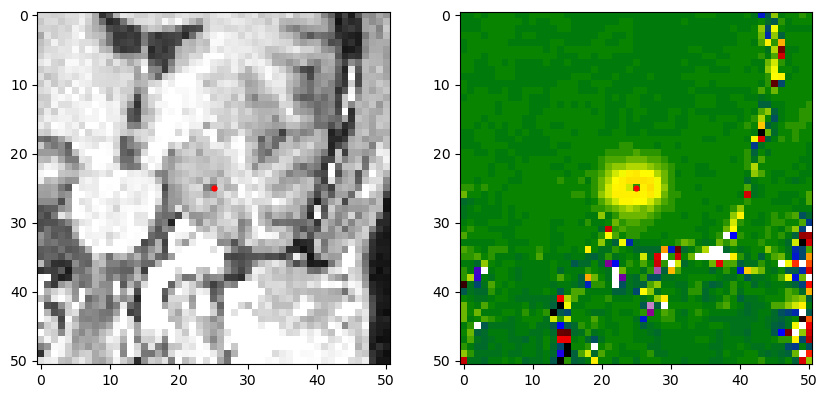

In [38]:
probesEye =  Image.open(png_dir)
tempPng = Image.open(temp_dir)
tempPng = tempPng.convert("L") #Convert to RBG in order to apply Monteris_cmap

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(probesEye, cmap = 'gray')
plt.scatter(laser_point[0], laser_point[1], color = 'red', s = 12)

plt.subplot(1, 2, 2)
plt.imshow(tempPng, cmap = Monteris_cmap, vmin = 0, vmax = 255)
plt.scatter(laser_point[0], laser_point[1], color = 'red', s = 12)